In [1]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload mode
%autoreload 2

# CoralNet Annotation EDA

In [2]:
import io
import pandas as pd
import numpy as np 

import tqdm
import warnings

from matplotlib import pyplot as plt

In [3]:
import boto3

import requests 
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse

def check_s3_prefix_exists(bucket_name, s3_prefix, source_id, specific_file = "annotations.csv"):
    s3 = boto3.client("s3")
    prefix = f"{s3_prefix}/s{source_id}/{specific_file}"

    response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix, MaxKeys=1)

    if "Contents" in response:
        # print(f"Prefix exists: {prefix}")
        return True
    else:
        # print(f"Prefix does not exist: {prefix}")
        return False

In [4]:
#Map to CoralNet labelspace

mapping_endpoint ="https://api.datamermaid.org/v1/classification/labelmappings/?provider=CoralNet" 

response = requests.get(mapping_endpoint)
data = response.json()
labelset = data["results"]

while data["next"]:
    response = requests.get(data["next"])
    data = response.json()
    labelset.extend(data["results"])
label_mapping = {
    int(label["provider_id"]): label["benthic_attribute_name"] for label in labelset
}

In [5]:
bucket_name = "dev-datamermaid-sm-sources"
prefix = "coralnet-public-images"
s3 = boto3.client("s3")

In [6]:
df_labelset100 = pd.read_csv("dataframes/mapped_to_mermaid_attributes.csv")
df_labelset100_top = df_labelset100[df_labelset100["top100"]=="1"]

In [9]:
df_labelset100_top.head()

,id,created on,created by,updated on,updated by,status,name,CoralNetAnnotations,top100,priority,priority_notes,parent,Life history list,Region list
0,20090bf4-868e-431b-974c-ab9be5bbdb5f,2018-04-04 19:03:43.852250+00:00,NaN,2022-08-10 12:42:00.960645+00:00,NaN,superuser approved,Turf algae,7443962,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
1,b76bca12-884b-4404-bb9f-97d505b0fe58,2018-04-04 19:03:43.652901+00:00,NaN,2019-02-04 21:52:07.497930+00:00,NaN,superuser approved,Sand,3728358,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
2,09226989-50e7-4c40-bd36-5bcef32ee7a1,2018-04-04 19:03:43.100527+00:00,NaN,2019-02-04 21:52:07.522976+00:00,NaN,superuser approved,Macroalgae,2968785,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
3,f4df7abd-3d51-42fb-8cab-5102b95fad8e,2018-04-04 19:03:41.511370+00:00,NaN,2023-11-09 01:44:12.240717+00:00,NaN,superuser approved,Crustose coralline algae,1842258,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
5,d9086647-3a82-4634-97bc-6e10347af39b,2018-04-04 19:03:43.623738+00:00,NaN,2018-04-04 19:03:43.623757+00:00,NaN,superuser approved,Bare substrate,1197412,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."


In [8]:
from mermaidseg.datasets.concepts import initialize_benthic_hierarchy
hierarchy_dict = initialize_benthic_hierarchy()

# Initialize and preprocess annotations and images

In [10]:
s3_key = f"{prefix}/temporary/df_annotations.csv"
obj = s3.get_object(Bucket=bucket_name, Key=s3_key)
df_annotations = pd.read_csv(obj["Body"])

In [11]:
df_annotations.head()

,source_id,image_id,Status,Row,Column,Label ID
0,23,12805,Confirmed,735,1008,112
1,23,12805,Confirmed,663,1682,106
2,23,12805,Confirmed,955,1737,106
3,23,12805,Confirmed,1034,1431,105
4,23,12805,Confirmed,851,2036,106


In [12]:
df_annotations["Status"].value_counts()

Status
Confirmed       21680834
Unconfirmed     13359126
Unclassified        5562
Name: count, dtype: int64

In [13]:
s3_key = f"{prefix}/temporary/df_images.csv"
obj = s3.get_object(Bucket=bucket_name, Key=s3_key)
df_images = pd.read_csv(obj["Body"])

In [14]:
df_images.head()

,index,source_id,image_id,Status,Row,Column,Label ID,validation
0,0,23,12805,Confirmed,735,1008,112,True
1,20,23,12806,Confirmed,632,1307,106,True
2,40,23,12807,Confirmed,595,1083,112,True
3,60,23,12808,Confirmed,668,2477,106,True
4,80,23,12809,Confirmed,440,2324,106,True


In [15]:
df_images["validation"].value_counts()

validation
True     723364
False     71113
Name: count, dtype: int64

In [16]:
df_images = df_images[df_images["validation"]==True]

In [17]:
df_annotations = df_annotations[df_annotations["Status"]=="Confirmed"]
df_annotations = df_annotations.merge(df_images[["image_id"]], on="image_id", how="inner")

In [18]:
print("After filtering, we are left with {} annotations across {} images".format(df_annotations.shape[0], df_annotations["image_id"].nunique()))

After filtering, we are left with 20975600 annotations across 723364 images


## Map to the MERMAID labelspace 

In [19]:
df_annotations["MERMAID Label"] = df_annotations["Label ID"].map(label_mapping)

In [20]:
MERMAID_labelset = df_annotations["MERMAID Label"].unique().tolist()

## Map to the MERMAID top100 labelspace

In [31]:
label_mapping_top100 = {}
for label in MERMAID_labelset:
    if label in df_labelset100_top["name"].values:
        label_mapping_top100[label] = label
    else:
        # If not in top 100, find the closest match in the hierarchy
        if label in hierarchy_dict:
            parent = hierarchy_dict[label]
            while parent is not None:
                if parent in df_labelset100_top["name"].values:
                    label_mapping_top100[label] = parent
                    break
                parent = hierarchy_dict[parent]
            if parent is None:
                label_mapping_top100[label] = "No Top Level Category"
        elif pd.isna(label):
            label_mapping_top100[label] = None
        else:
            label_mapping_top100[label] = "Other"

In [35]:
print("Number of 'Other' labels:", list(label_mapping_top100.values()).count("Other"))
print("Number of 'No Top Level Category' labels:", list(label_mapping_top100.values()).count("No Top Level Category"))

Number of 'Other' labels: 0
Number of 'No Top Level Category' labels: 24


In [36]:
df_annotations["MERMAID Label Top100"] = df_annotations["MERMAID Label"].map(label_mapping_top100)

# Source EDA

In [37]:
df_source = (
    df_annotations.groupby("source_id")
    .agg(
        image_count=("image_id", "nunique"),
        annotations_count=("image_id", "size"),
        num_labels=("Label ID", "nunique"),
        num_labels_MERMAID=("MERMAID Label", "nunique"),
        num_labels_MERMAID_top100=("MERMAID Label Top100", "nunique"),
    )
    .reset_index()
)

df_source.head()

,source_id,image_count,annotations_count,num_labels,num_labels_MERMAID,num_labels_MERMAID_top100
0,23,750,15000,20,16,14
1,57,82,8200,27,20,16
2,69,100,4000,5,5,5
3,70,300,12000,16,16,13
4,109,3942,197100,78,51,30


In [61]:
csv_buffer = io.StringIO()
df_source.to_csv(csv_buffer, index=False)

s3_key = f"{prefix}/temporary/df_source_EDA.csv"

# Upload to S3
s3.put_object(
    Bucket=bucket_name, Key=s3_key, Body=csv_buffer.getvalue(), ContentType="text/csv"
)

{'ResponseMetadata': {'RequestId': 'FV8P968FY4W94CT6',
  'HostId': 'QcZ62NAQngEj98Y6Mnu6g+QhJVIM4JSSMBRzmyUjDzNItgvRitVWCOuoGB10EwBBfer4qIXjFXU=',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'QcZ62NAQngEj98Y6Mnu6g+QhJVIM4JSSMBRzmyUjDzNItgvRitVWCOuoGB10EwBBfer4qIXjFXU=',
   'x-amz-request-id': 'FV8P968FY4W94CT6',
   'date': 'Mon, 04 May 2026 03:46:00 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"2814bbc302bb75ca9523bbba27eaf2ce"',
   'x-amz-checksum-crc32': 'Pqx2bw==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"2814bbc302bb75ca9523bbba27eaf2ce"',
 'ChecksumCRC32': 'Pqx2bw==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

In [38]:
df_source.shape

(1239, 6)

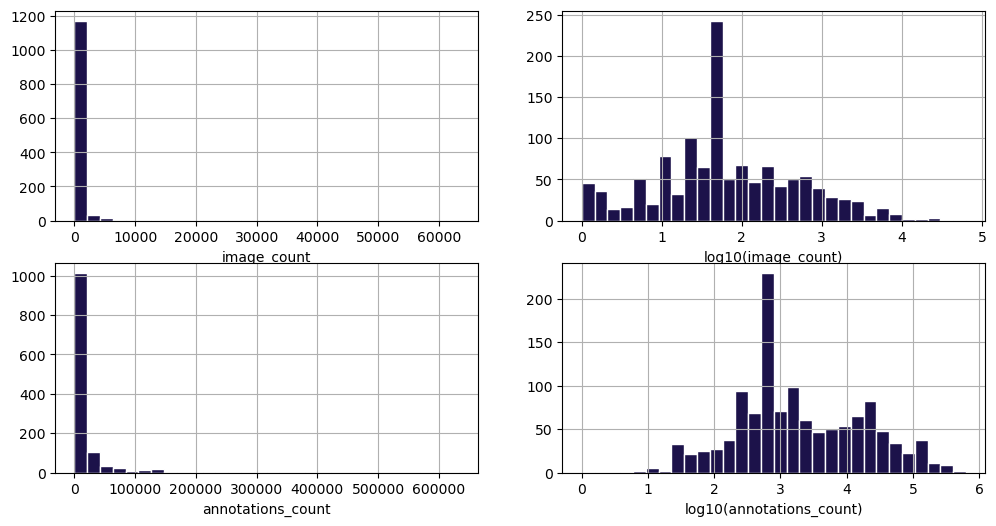

In [39]:
fig, ax = plt.subplots(figsize=(12, 6), nrows = 2, ncols = 2)
df_source["image_count"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[0,0])
ax[0, 0].set_xlabel("image_count")

np.log10(df_source["image_count"]).hist(
    bins=30, edgecolor="white", color="#1C124A", ax=ax[0, 1]
)
ax[0, 1].set_xlabel("log10(image_count)")

df_source["annotations_count"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[1,0])
ax[1,0].set_xlabel("annotations_count")

np.log10(df_source["annotations_count"]).hist(
    bins=30, edgecolor="white", color="#1C124A", ax=ax[1, 1]
)
ax[1, 1].set_xlabel("log10(annotations_count)")
plt.show()

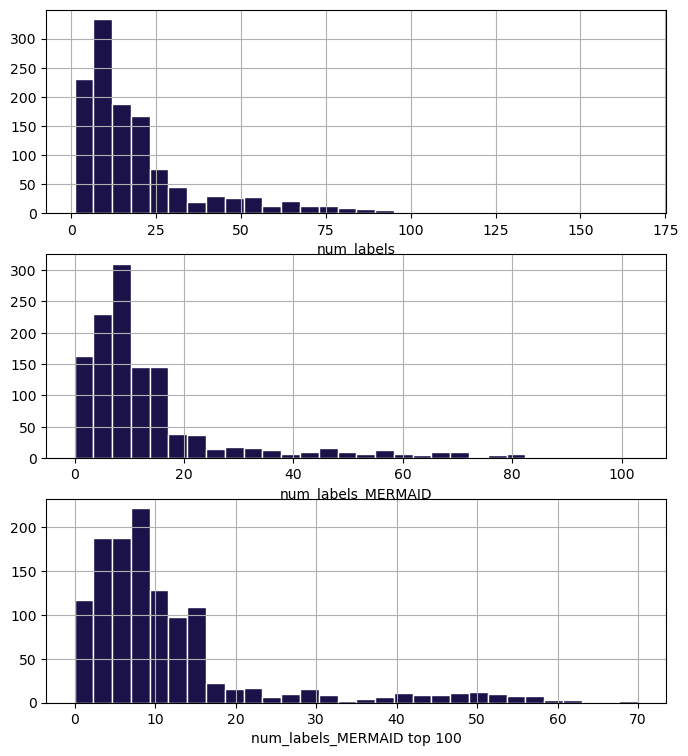

In [41]:
fig, ax = plt.subplots(figsize=(8, 9), nrows = 3)
df_source["num_labels"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[0])
ax[0].set_xlabel("num_labels")

df_source["num_labels_MERMAID"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[1])
ax[1].set_xlabel("num_labels_MERMAID")

df_source["num_labels_MERMAID_top100"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[2])
ax[2].set_xlabel("num_labels_MERMAID top 100")
plt.show()

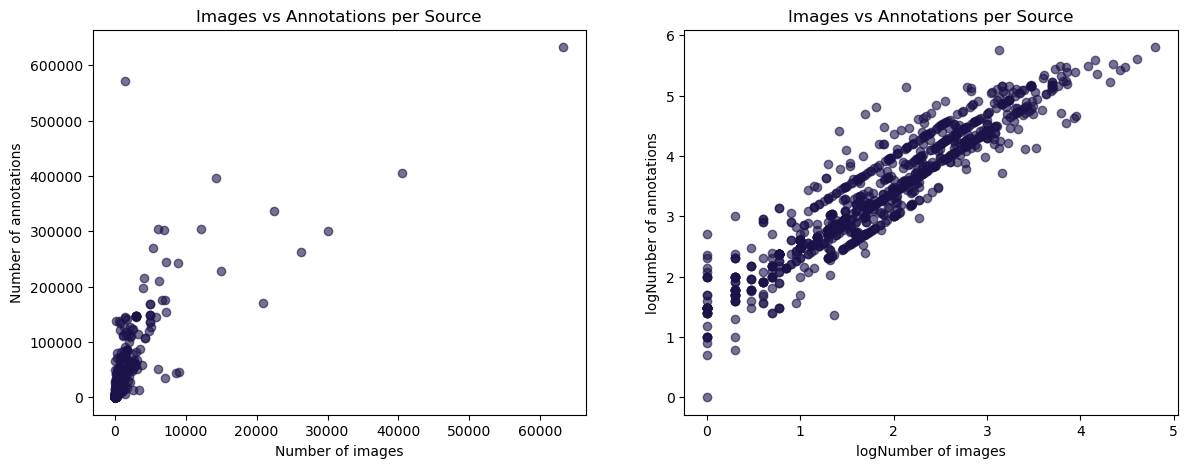

In [42]:
fig, ax = plt.subplots(figsize=(14, 5), ncols = 2)
ax[0].scatter(
    df_source["image_count"],
    df_source["annotations_count"],
    alpha=0.6,
    color="#1C124A"
)   

ax[0].set_xlabel("Number of images")
ax[0].set_ylabel("Number of annotations")
ax[0].set_title("Images vs Annotations per Source")

ax[1].scatter(
    np.log10(df_source["image_count"]),
    np.log10(df_source["annotations_count"]),
    alpha=0.6,
    color="#1C124A"
)   

ax[1].set_xlabel("logNumber of images")
ax[1].set_ylabel("logNumber of annotations")
ax[1].set_title("Images vs Annotations per Source")
plt.show()

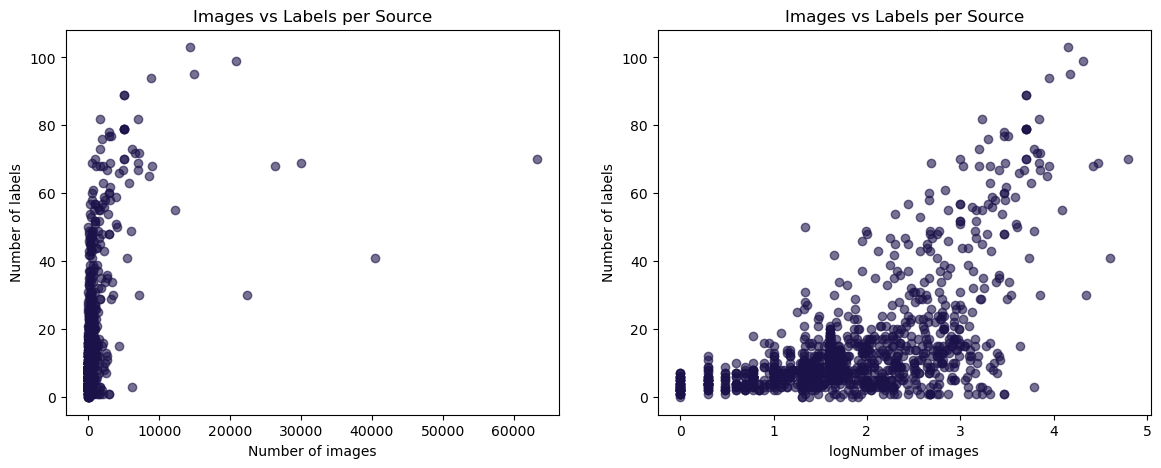

In [43]:
fig, ax = plt.subplots(figsize=(14, 5), ncols = 2)
ax[0].scatter(
    df_source["image_count"],
    df_source["num_labels_MERMAID"],
    alpha=0.6,
    color="#1C124A"
)   
    
ax[0].set_xlabel("Number of images")
ax[0].set_ylabel("Number of labels")
ax[0].set_title("Images vs Labels per Source")

ax[1].scatter(
    np.log10(df_source["image_count"]),
    df_source["num_labels_MERMAID"],
    alpha=0.6,
    color="#1C124A"
)   

ax[1].set_xlabel("logNumber of images")
ax[1].set_ylabel("Number of labels")
ax[1].set_title("Images vs Labels per Source")
plt.show()

In [45]:
num_images_threshold = 20
num_annotations_threshold = 500
num_labels_threshold = 30
num_labels_MERMAID_threshold = 30

In [46]:
print(f"Sources with more than {num_images_threshold} images: {(df_source['image_count'] > num_images_threshold).sum()}")
print(f"Sources with more than {num_annotations_threshold} annotations: {(df_source['annotations_count'] > num_annotations_threshold).sum()}")
print(f"Sources with more than {num_labels_threshold} labels: {(df_source['num_labels'] > num_labels_threshold).sum()}")
print(f"Sources with more than {num_labels_MERMAID_threshold} MERMAID mapped labels: {(df_source['num_labels_MERMAID_top100'] > num_labels_MERMAID_threshold).sum()}")

Sources with more than 20 images: 906
Sources with more than 500 annotations: 925
Sources with more than 30 labels: 223
Sources with more than 30 MERMAID mapped labels: 107


In [47]:
print(f"Sources with all requirements (original): {((df_source['image_count'] > num_images_threshold) & 
                                        (df_source['annotations_count'] > num_annotations_threshold) & 
                                        (df_source['num_labels'] > num_labels_threshold)).sum()}")

Sources with all requirements (original): 220


In [49]:
print(f"Sources with all requirements (MERMAID): {((df_source['image_count'] > num_images_threshold) & 
                                        (df_source['annotations_count'] > num_annotations_threshold) & 
                                        (df_source['num_labels_MERMAID_top100'] > num_labels_MERMAID_threshold)).sum()}")

Sources with all requirements (MERMAID): 107


In [50]:
num_images_threshold = 100
num_annotations_threshold = 1000
num_labels_MERMAID_threshold = 10

print(f"Sources with all updated (example) requirements (MERMAID): {((df_source['image_count'] > num_images_threshold) & 
                                        (df_source['annotations_count'] > num_annotations_threshold) & 
                                        (df_source['num_labels_MERMAID_top100'] > num_labels_MERMAID_threshold)).sum()}")

Sources with all updated (example) requirements (MERMAID): 263


## Label Distribution

In [55]:
label_id_summary = (
    df_annotations
    .groupby(["Label ID"])
    .agg(
        num_annotations=("Label ID", "size"),
        num_images=("image_id", "nunique"),
        num_sources =("source_id", "nunique"),
    )
    .reset_index()
)

label_id_summary.head()

,Label ID,num_annotations,num_images,num_sources
0,58,1848,1275,69
1,59,349074,57623,129
2,60,15412,7185,95
3,61,8107,4422,88
4,62,7943,4506,27


In [62]:
csv_buffer = io.StringIO()
label_id_summary.to_csv(csv_buffer, index=False)

s3_key = f"{prefix}/temporary/df_label_CoralNet_EDA.csv"

# Upload to S3
s3.put_object(
    Bucket=bucket_name, Key=s3_key, Body=csv_buffer.getvalue(), ContentType="text/csv"
)

{'ResponseMetadata': {'RequestId': '10MPVYDRQ9PTJ4V3',
  'HostId': 'k3/mkGV6TcYeb67p07BLv207MLlqVtHsXSB2BXJRRUjwCRhMgnP92PzEb75G719JICxIpQ+1jsU=',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'k3/mkGV6TcYeb67p07BLv207MLlqVtHsXSB2BXJRRUjwCRhMgnP92PzEb75G719JICxIpQ+1jsU=',
   'x-amz-request-id': '10MPVYDRQ9PTJ4V3',
   'date': 'Mon, 04 May 2026 03:46:14 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"0a0a7cdceffd3b0d287169a79e2a032c"',
   'x-amz-checksum-crc32': '+/l+zA==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"0a0a7cdceffd3b0d287169a79e2a032c"',
 'ChecksumCRC32': '+/l+zA==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

In [56]:
label_id_summary_MERMAID = (
    df_annotations
    .groupby(["MERMAID Label Top100"])
    .agg(
        num_annotations=("MERMAID Label Top100", "size"),
        num_images=("image_id", "nunique"),
        num_sources =("source_id", "nunique"),
    )
    .reset_index()
)

label_id_summary_MERMAID.head()

,MERMAID Label Top100,num_annotations,num_images,num_sources
0,Acanthaster planci,70,37,13
1,Acanthastrea,2384,1731,72
2,Acropora,480052,85356,240
3,Acropora cervicornis,17438,1454,34
4,Acropora palmata,1556,185,18


In [63]:
csv_buffer = io.StringIO()
label_id_summary_MERMAID.to_csv(csv_buffer, index=False)

s3_key = f"{prefix}/temporary/df_label_MERMAID_Top100_EDA.csv"

# Upload to S3
s3.put_object(
    Bucket=bucket_name, Key=s3_key, Body=csv_buffer.getvalue(), ContentType="text/csv"
)

{'ResponseMetadata': {'RequestId': 'NNVX14YH824FNATZ',
  'HostId': 'ckKQe+s+gUnObqJRyTBCbev42KFSVjQfdN9B2jfrR9p7ZsI5gU3F4TSW21Kxsiw9SzYqqA9i3To=',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'ckKQe+s+gUnObqJRyTBCbev42KFSVjQfdN9B2jfrR9p7ZsI5gU3F4TSW21Kxsiw9SzYqqA9i3To=',
   'x-amz-request-id': 'NNVX14YH824FNATZ',
   'date': 'Mon, 04 May 2026 03:46:27 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"66185097b7b64f73a21539b4234d364f"',
   'x-amz-checksum-crc32': '6JE4fQ==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"66185097b7b64f73a21539b4234d364f"',
 'ChecksumCRC32': '6JE4fQ==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

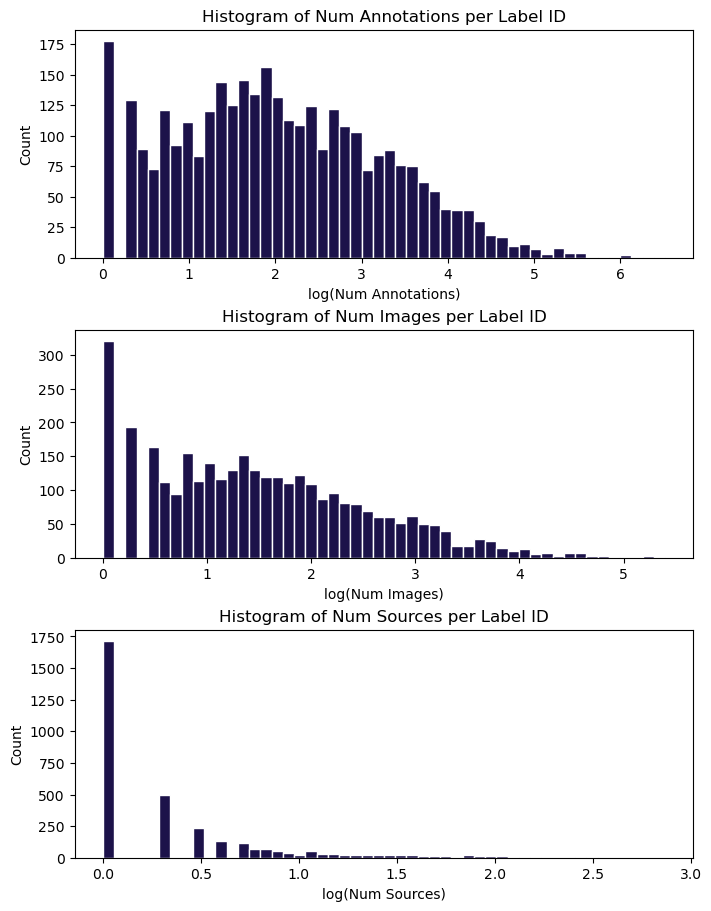

In [ ]:
fig, ax = plt.subplots(figsize=(7, 9), nrows = 3, layout = "compressed")
ax[0].hist(np.log10(label_id_summary["num_annotations"]), bins=50, edgecolor="white", color = "#1C124A")
ax[0].set_xlabel("log(Num Annotations)")
ax[0].set_ylabel("Count")
ax[0].set_title("Histogram of Num Annotations per Label ID")

ax[1].hist(np.log10(label_id_summary["num_images"]), bins=50, edgecolor="white", color = "#1C124A")
ax[1].set_xlabel("log(Num Images)")
ax[1].set_ylabel("Count")
ax[1].set_title("Histogram of Num Images per Label ID")

ax[2].hist(np.log10(label_id_summary["num_sources"]), bins=50, edgecolor="white", color = "#1C124A")
ax[2].set_xlabel("log(Num Sources)")
ax[2].set_ylabel("Count")
ax[2].set_title("Histogram of Num Sources per Label ID")

plt.show()

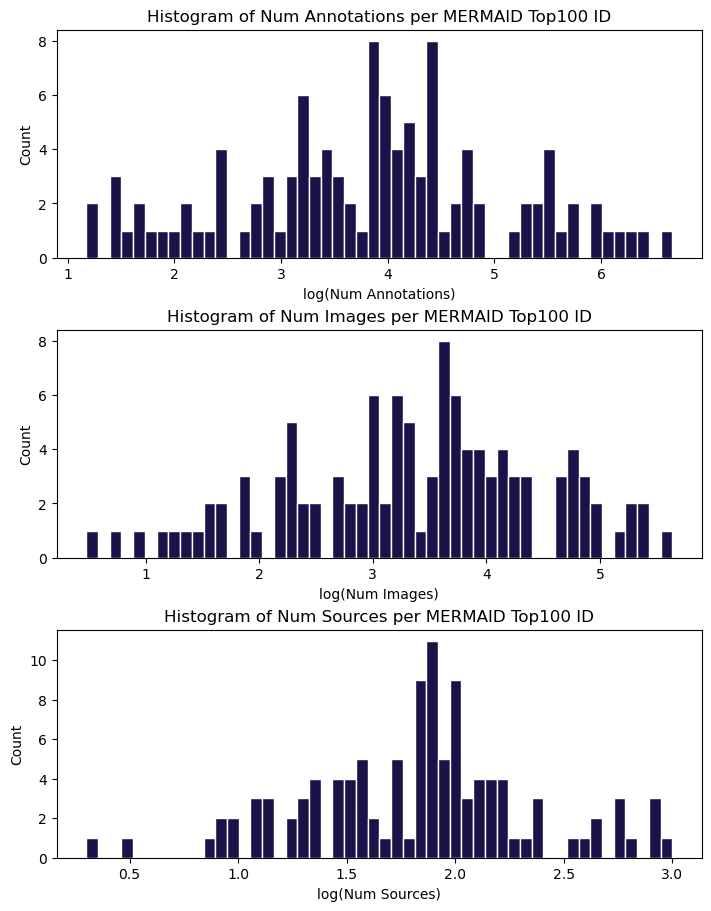

In [59]:
fig, ax = plt.subplots(figsize=(7, 9), nrows = 3, layout = "compressed")
ax[0].hist(np.log10(label_id_summary_MERMAID["num_annotations"]), bins=50, edgecolor="white", color = "#1C124A")
ax[0].set_xlabel("log(Num Annotations)")
ax[0].set_ylabel("Count")
ax[0].set_title("Histogram of Num Annotations per MERMAID Top100 ID")

ax[1].hist(np.log10(label_id_summary_MERMAID["num_images"]), bins=50, edgecolor="white", color = "#1C124A")
ax[1].set_xlabel("log(Num Images)")
ax[1].set_ylabel("Count")
ax[1].set_title("Histogram of Num Images per MERMAID Top100 ID")

ax[2].hist(np.log10(label_id_summary_MERMAID["num_sources"]), bins=50, edgecolor="white", color = "#1C124A")
ax[2].set_xlabel("log(Num Sources)")
ax[2].set_ylabel("Count")
ax[2].set_title("Histogram of Num Sources per MERMAID Top100 ID")

plt.show()